In [1]:
import pandas as pd 
df=pd.read_csv("1.csv")
df


,weight,texture,color,fruit
0,150,s,red,apple
1,170,r,orange,orange
2,140,s,green,apple
3,180,r,orange,orange
4,160,s,red,appple
5,155,r,yellow,orange


In [2]:
import numpy as np
df['texture']=np.where(df['texture']=='s',0,1)
df

,weight,texture,color,fruit
0,150,0,red,apple
1,170,1,orange,orange
2,140,0,green,apple
3,180,1,orange,orange
4,160,0,red,appple
5,155,1,yellow,orange


In [4]:
df['color']=np.where(df["color"]=="red",0,np.where(df['color']=='orange',1,np.where(df['color']=='green',2,3)))
df

,weight,texture,color,fruit
0,150,0,0,apple
1,170,1,1,orange
2,140,0,2,apple
3,180,1,1,orange
4,160,0,0,appple
5,155,1,3,orange


In [5]:
df.columns

Index(['weight', 'texture', 'color', 'fruit'], dtype='object')

In [6]:
x=df[['weight', 'texture', 'color']]
y=df['fruit']
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy',n_estimators=50,random_state=42)
rf_classifier= rf_classifier.fit(x,y)
prediction = rf_classifier.predict(x)
print(prediction)

['apple' 'orange' 'apple' 'orange' 'appple' 'orange']


In [18]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y,prediction)
print(cm)

[[2 0 0]
 [0 1 0]
 [0 0 3]]


In [14]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(criterion="entropy",random_state=1)
model = dtree.fit(x,y)
prediction = model.predict(x)
print(prediction)


['apple' 'orange' 'apple' 'orange' 'appple' 'orange']


IndexError: list index out of range

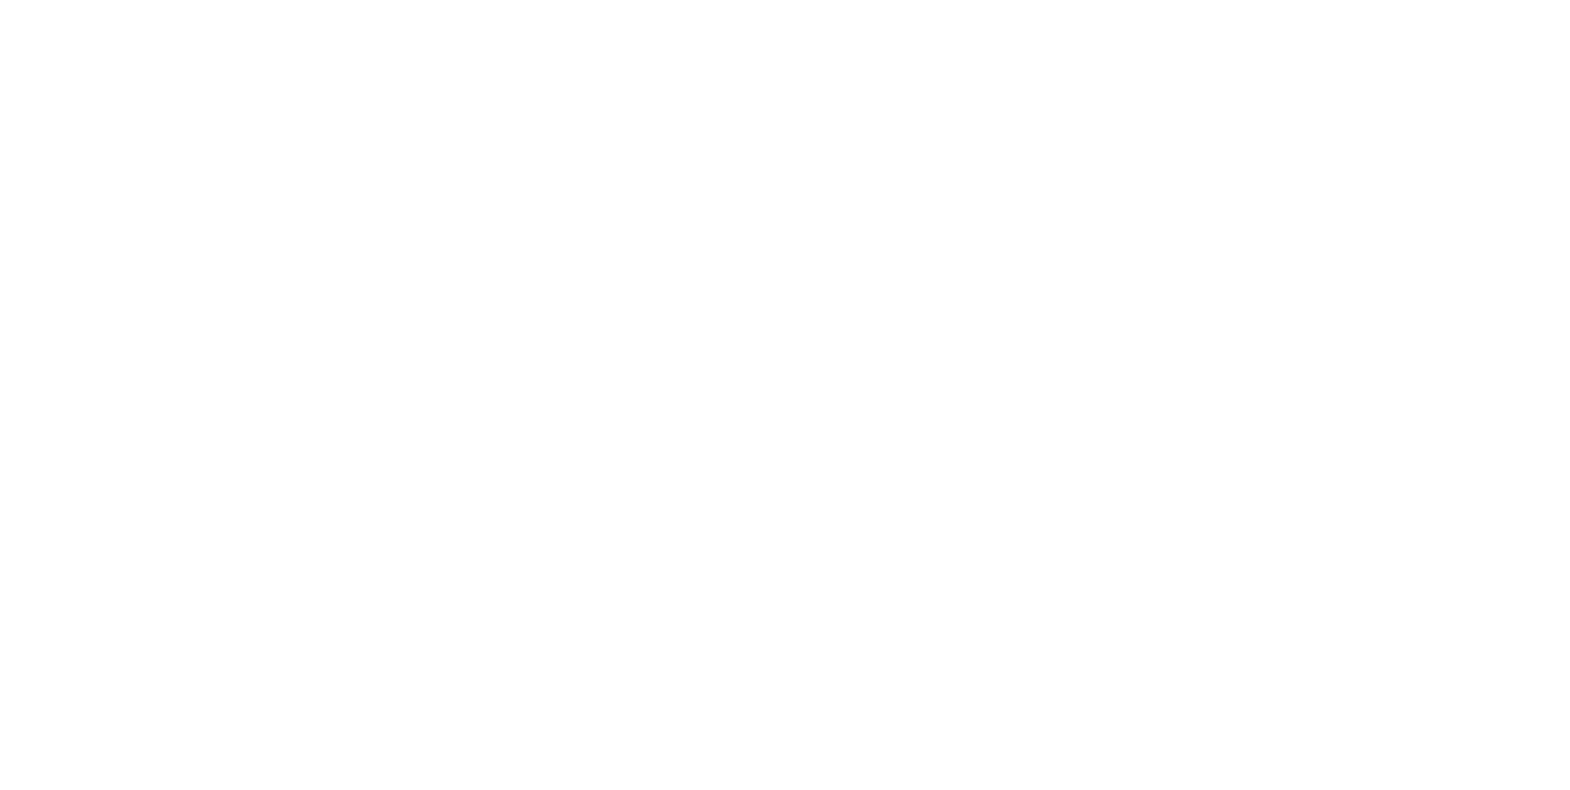

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(30,10))
chosen_tree=rf_classifier.estimators_[0]
plot_tree(chosen_tree,feature_names=x.columns,class_names=['apple','orange'],filled=True,rounded=True)
plt.show()

In [22]:
import pandas as pd 
df=pd.read_csv("diabetes.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [21]:
from sklearn.svm import SVC

In [23]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [24]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [32]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf',C=10,random_state=1)
model = classifier.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0]


In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[91  8]
 [27 28]]


In [34]:
print("Acucuracy score :",accuracy_score(y_test,y_pred))

Acucuracy score : 0.7727272727272727
